In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw5.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 5: Putting it all together 
### Associated lectures: All material till lecture 13 

<div class="alert-warning">
    
## Instructions  
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Before you start  

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W2/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
  
- Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions) for detailed guidance on completing and submitting assignments. 

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   
### Before submitting  

- **Run all cells** (▶▶ button) to ensure the notebook executes cleanly from top to bottom.

  - Execution counts must start at **1** and be sequential.
    
  - Notebooks with missing outputs or errors may lose marks.

- **Do not upload or push data files** used in this lab to GitHub or Gradescope. (A `.gitignore` is provided to prevent this.)  


### Submitting on Gradescope  

- Upload **only** your `.ipynb` file (with outputs shown) and any required output files. Do **not** submit extra files.
  
- If needed, refer to the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- If your notebook is too large to render, also upload a **Web PDF** or **HTML** version.  
  - You can create one using **File $\rightarrow$ Save and Export Notebook As**.  
  - If you get an error when creating a PDF, try running the following commands in your lab directory:  

    ```bash
    conda install -c conda-forge nbconvert-playwright
    jupyter nbconvert --to webpdf lab1.ipynb
    ```  

  - Ensure all outputs are visible in your PDF or HTML file; TAs cannot grade your work if outputs are missing.

</div>


_Note: Unlike previous assignments, this one is open-ended and project-style. Treat it as an opportunity to explore, experiment, and learn._

<!-- BEGIN QUESTION -->

## Imports

<div class="alert alert-warning">
    
Imports
    
</div>

_Points:_ 0

In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.feature_selection import RFECV
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
import shap
from sklearn.metrics import accuracy_score, recall_score, f1_score

<!-- END QUESTION -->

## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<br><br>

<!-- BEGIN QUESTION -->

## 1. Pick your problem and explain the prediction problem
<hr>
rubric={points:3}

In this mini project, you have the option to choose on which dataset you will be working on. The tasks you will need to carry on will be similar, independently of your choice.

### Option 1
You can choose to work on a classification problem of predicting whether a credit card client will default or not. 
For this problem, you will use [Default of Credit Card Clients Dataset](https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset). In this data set, there are 30,000 examples and 24 features, and the goal is to estimate whether a person will default (fail to pay) their credit card bills; this column is labeled "default.payment.next.month" in the data. The rest of the columns can be used as features. You may take some ideas and compare your results with [the associated research paper](https://www.sciencedirect.com/science/article/pii/S0957417407006719), which is available through [the UBC library](https://www.library.ubc.ca/). 


### Option 2
You can choose to work on a regression problem using a [dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data) of New York City Airbnb listings from 2019. As usual, you'll need to start by downloading the dataset, then you will try to predict `reviews_per_month`, as a proxy for the popularity of the listing. Airbnb could use this sort of model to predict how popular future listings might be before they are posted, perhaps to help guide hosts create more appealing listings. In reality they might instead use something like vacancy rate or average rating as their target, but we do not have that available here.

> Note there is an updated version of this dataset with more features available [here](http://insideairbnb.com/). The features were are using in `listings.csv.gz` for the New York city datasets. You will also see some other files like `reviews.csv.gz`. For your own interest you may want to explore the expanded dataset and try your analysis there. However, please submit your results on the dataset obtained from Kaggle.


<div class="alert alert-info">
    
**Your tasks:**

1. Review the available datasets and choose the one you find most interesting. It may help to read through the dataset documentation on Kaggle before deciding.
2. Once you've selected a dataset, take time to understand the problem it represents and the meaning of each feature. Use the Kaggle documentation to guide you.
3. Download the dataset and load it into a pandas DataFrame.
4. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>

<div class="alert alert-warning">
    
Solution_1
    
</div>

_Points:_ 3

The goal of using this dataset is to predict whether a credit card client will default on their payment on the next month based on a selection of the other features. 
My initial worry about this dataset is multicollinearity. Many of these features are like each other but just set in different times (PAY, BILL_AMT, and PAY_AMT). I believe I may need to address this issue as I go through testing. Even after dealing with multicollinearity issues which may involve toning down the usage of these features, I worry about what other features that I can rely on as many of the others are protected features such as age and sex. 

In [3]:
df = pd.read_csv("UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [4]:
X = df.drop(columns=['ID', 'SEX', 'MARRIAGE', 'AGE', 'default.payment.next.month'])
y = df['default.payment.next.month']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

In [5]:
X_train.head()

,LIMIT_BAL,EDUCATION,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
16395,320000.0,1,0,0,0,0,0,0,29026.0,28179.0,28695.0,19370.0,10155.0,3788.0,5000.0,5018.0,1000.0,3000.0,0.0,7013.0
21448,440000.0,1,-1,-1,-1,0,0,0,777.0,612.0,87426.0,171244.0,150897.0,117870.0,612.0,87426.0,130007.0,3018.0,15000.0,51663.0
20034,160000.0,3,-2,-2,-2,-2,-2,-2,-18.0,-18.0,-18.0,-18.0,-18.0,-18.0,0.0,0.0,0.0,0.0,0.0,0.0
25755,120000.0,2,0,0,0,0,0,0,101596.0,102860.0,104694.0,103058.0,71095.0,47379.0,3706.0,5502.0,4204.0,3017.0,2005.0,1702.0
1438,50000.0,2,1,2,0,0,0,0,48153.0,46885.0,27168.0,27585.0,27910.0,27380.0,0.0,1400.0,1200.0,1500.0,1000.0,1500.0


In [6]:
y_train.head()

16395    0
21448    0
20034    0
25755    0
1438     0
Name: default.payment.next.month, dtype: int64

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

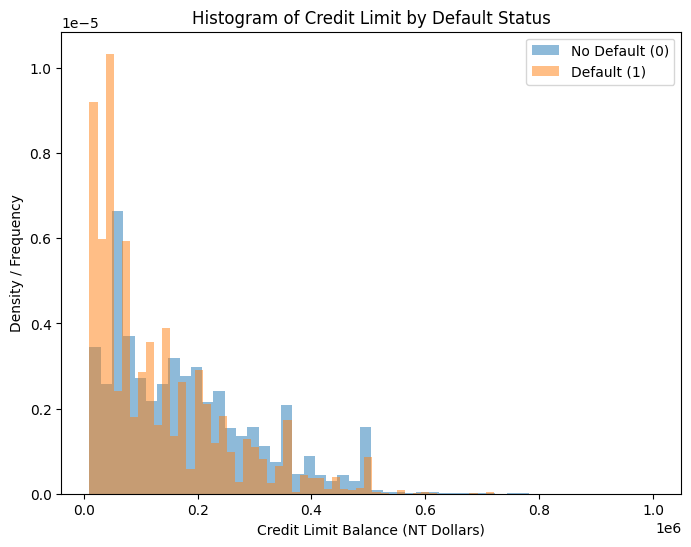

In [7]:
plt.figure(figsize=(8, 6))

plt.hist(X_train[y_train == 0]['LIMIT_BAL'].dropna(), bins=50, alpha=0.5, density=True, label='No Default (0)')
plt.hist(X_train[y_train == 1]['LIMIT_BAL'].dropna(), bins=50, alpha=0.5, density=True, label='Default (1)')

plt.xlabel('Credit Limit Balance (NT Dollars)')
plt.ylabel('Density / Frequency')
plt.title('Histogram of Credit Limit by Default Status')
plt.legend()

plt.show()

This histogram reveals that those with a lower credit limit make up a high amount of the total defaults in the dataset.  

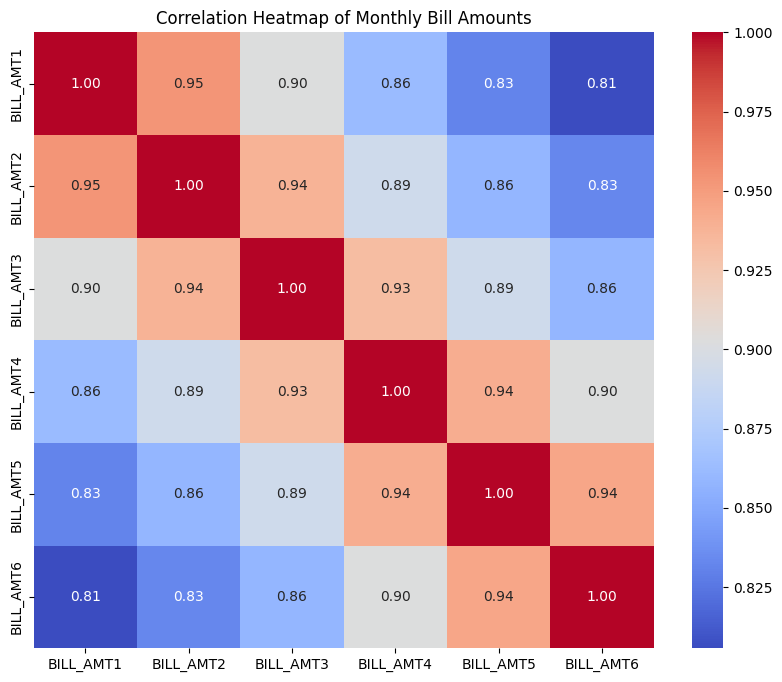

In [8]:

plt.figure(figsize=(10, 8))
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

sns.heatmap(X_train[bill_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap of Monthly Bill Amounts')
plt.show()

This heat map reveals the multicollinearity issues that using this dataset would result in by comparing the correlation between the different months' BILL_AMT values (all over 0.8). 

In [9]:
y_train.value_counts(normalize=True)

default.payment.next.month
0    0.776762
1    0.223238
Name: proportion, dtype: float64

This summary statistic reveals the representation issues of this dataset as a high majority of people have not defaulted. 

In [10]:
X_train.describe()

,LIMIT_BAL,EDUCATION,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,2.100000e+04,21000.000000,21000.000000,21000.000000,21000.000000
mean,167880.651429,1.852143,-0.015429,-0.137095,-0.171619,-0.225238,-0.264429,-0.295095,51107.566762,49126.824810,47010.414095,43486.610905,40428.518333,38767.202667,5673.585143,5.895027e+03,5311.432286,4774.021381,4751.850095,5237.762190
std,130202.682167,0.792961,1.120465,1.194506,1.196123,1.168556,1.137205,1.147992,73444.143025,71400.032096,69035.759516,64843.303993,61187.200817,59587.689549,17033.241454,2.180143e+04,18377.997079,15434.136142,15228.193125,18116.846563
min,10000.000000,0.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-15308.000000,-67526.000000,-157264.000000,-50616.000000,-61372.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3649.250000,2925.750000,2663.750000,2293.750000,1739.500000,1215.750000,1000.000000,8.200000e+02,390.000000,266.000000,234.000000,110.750000
50%,140000.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22284.000000,21002.500000,20088.500000,19102.500000,18083.000000,16854.500000,2100.000000,2.007000e+03,1809.500000,1500.000000,1500.000000,1500.000000
75%,240000.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,66979.750000,63795.250000,59895.000000,54763.250000,50491.000000,49253.750000,5007.250000,5.000000e+03,4628.500000,4021.250000,4016.000000,4000.000000
max,1000000.000000,6.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,855086.000000,891586.000000,927171.000000,961664.000000,873552.000000,1.227082e+06,896040.000000,621000.000000,426529.000000,528666.000000


Looking at the means of the monthly BILL_AMT values, these show a general increase which may indicate that there are other macro factors at play such as a weakening economy and hike in cost of living. 

**Record your observations: Summarize your initial observations about the dataset based on your EDA.**

The dataset features a good predictor in LIMIT_BAL, as its histogram showcases the disparity between those that defaulted and those that didn't. Despite this, it suffers from multicollinearity problems between its features due to how they measure the same things except in different months. Finally, the dataset isn't representative. There is a lack of representation of people that didn't default. If one were to run a dummy model on this dataset, it would achieve 78 percent accuracy by simply guessing everyone as not defaulting. 

**Select evaluation metrics: Choose one or more appropriate metrics for assessing model performance and briefly justify your choice.**

I believe recall can be a great initial metric for assessing model performance. As it primarily measures what total positives were actually positives, this can show how much the model is overpredicting those that defaulted due to the unrepresentative dataset. Another metric is the F1 score as this helps balance the model and ensure it doesn't overpredict. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

In [11]:

def engineer_features(df):
    df_engineered = df.copy()
    
    pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    df_engineered['AVG_PAY_DELAY'] = df_engineered[pay_cols].mean(axis=1)
    
    df_engineered['BILL_TREND'] = df_engineered['BILL_AMT1'] - df_engineered['BILL_AMT6']
    
    ratio_cols = []
    for i in range(1, 7):
        bill_col = f'BILL_AMT{i}'
        pay_col = f'PAY_AMT{i}'
        ratio_col = f'PAY_RATIO_{i}'
        
        df_engineered[ratio_col] = np.where(
            df_engineered[bill_col] > 0, 
            df_engineered[pay_col] / df_engineered[bill_col], 
            1.0
        )
        ratio_cols.append(ratio_col)
        
    df_engineered['AVG_PAY_RATIO'] = df_engineered[ratio_cols].mean(axis=1)
    
    df_engineered.drop(columns=ratio_cols, inplace=True)
    
    bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
    pay_amt_cols = [f'PAY_AMT{i}' for i in range(1, 7)]
    
    cols_to_drop = pay_cols + bill_cols + pay_amt_cols
    df_engineered.drop(columns=cols_to_drop, inplace=True)
    
    return df_engineered

X_train = engineer_features(X_train)
X_test = engineer_features(X_test)

In [12]:
X_train

,LIMIT_BAL,EDUCATION,AVG_PAY_DELAY,BILL_TREND,AVG_PAY_RATIO
16395,320000.0,1,0.000000,25238.0,0.398573
21448,440000.0,1,-0.500000,-117093.0,24.280495
20034,160000.0,3,-2.000000,0.0,1.000000
25755,120000.0,2,0.000000,54217.0,0.037254
1438,50000.0,2,0.500000,20773.0,0.036504
...,...,...,...,...,...
28636,380000.0,2,0.333333,-2141.0,0.099916
17730,360000.0,1,-0.833333,-6941.0,0.948385
28030,50000.0,3,0.000000,38185.0,0.035902
15725,30000.0,2,0.000000,11844.0,0.046154


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

In [13]:
X_train.head()

,LIMIT_BAL,EDUCATION,AVG_PAY_DELAY,BILL_TREND,AVG_PAY_RATIO
16395,320000.0,1,0.0,25238.0,0.398573
21448,440000.0,1,-0.5,-117093.0,24.280495
20034,160000.0,3,-2.0,0.0,1.000000
25755,120000.0,2,0.0,54217.0,0.037254
1438,50000.0,2,0.5,20773.0,0.036504


| Column Name | Data Type | ColumnTransformer |
|---|---|---|
| LIMIT_BAL | Numeric | StandardScaler |
| EDUCATION | Ordinal | OneHotEncoder |
| AVG_PAY_DELAY | Numeric | StandardScaler | 
| BILL_TREND | Numeric | StandardScaler |
| AVG_PAY_RATIO | Numeric | StandardScaler |

In [14]:

numeric_features = ['LIMIT_BAL', 'AVG_PAY_DELAY', 'BILL_TREND', 'AVG_PAY_RATIO']
categorical_features = ['EDUCATION']

preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
    (OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    remainder="passthrough" 
)


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

In [15]:

dummy_pipe = make_pipeline(
    preprocessor, 
    DummyClassifier(strategy='prior') 
)

scoring_metrics = ['accuracy', 'recall', 'f1']

dummy_results = cross_validate(
    dummy_pipe, 
    X_train, 
    y_train, 
    cv=5, 
    scoring=scoring_metrics, 
    return_train_score=True
)

pd.DataFrame(dummy_results).mean()

fit_time          0.016257
score_time        0.016759
test_accuracy     0.776762
train_accuracy    0.776762
test_recall       0.000000
train_recall      0.000000
test_f1           0.000000
train_f1          0.000000
dtype: float64

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [16]:
lr_pipe = make_pipeline(
    preprocessor, 
    LogisticRegression(max_iter=1000, class_weight='balanced') 
)

In [17]:
lr_results = cross_validate(
    lr_pipe, 
    X_train, 
    y_train, 
    cv=5, 
    scoring=scoring_metrics, 
    return_train_score=True
)

import pandas as pd
pd.DataFrame(lr_results).mean()

fit_time          0.064702
score_time        0.022502
test_accuracy     0.619952
train_accuracy    0.620821
test_recall       0.645688
train_recall      0.646544
test_f1           0.431304
train_f1          0.432242
dtype: float64

In [18]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

tuning_results = []

for c in C_values:
    lr_pipe = make_pipeline(
        preprocessor, 
        LogisticRegression(C=c, max_iter=1000, class_weight='balanced') 
    )
    
    lr_results = cross_validate(
        lr_pipe, 
        X_train, 
        y_train, 
        cv=5, 
        scoring=scoring_metrics, 
        return_train_score=True
    )
    
    mean_scores = pd.DataFrame(lr_results).mean().to_dict()
    mean_scores['C_value'] = c
    tuning_results.append(mean_scores)

results_df = pd.DataFrame(tuning_results)
cols = ['C_value'] + [col for col in results_df.columns if col != 'C_value']
results_df = results_df[cols]

results_df

,C_value,fit_time,score_time,test_accuracy,train_accuracy,test_recall,train_recall,test_f1,train_f1
0,0.001,0.035227,0.019356,0.621714,0.622869,0.642490,0.643931,0.431241,0.432573
1,0.010,0.057078,0.022727,0.623714,0.624869,0.642702,0.642705,0.432598,0.433413
2,0.100,0.064423,0.018521,0.621190,0.622226,0.644621,0.645424,0.431697,0.432727
3,1.000,0.058885,0.017241,0.619952,0.620821,0.645688,0.646544,0.431304,0.432242
4,10.000,0.076165,0.019696,0.619667,0.620440,0.645688,0.646704,0.431120,0.432057
5,100.000,0.081141,0.020587,0.619571,0.620440,0.645688,0.646704,0.431059,0.432056


The model achieved its highest validation F1 score at a C value of 0.01. Overfitting never became an issue throughout an of the different C values as the model stayed within a consistent range of evaluation metrics. This shows that the model has low sensitivivty to C and may have reached a learning ceiling already. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

_Type your answer here, replacing this text._

In [19]:

models = {
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "LightGBM": LGBMClassifier(class_weight="balanced", random_state=42, verbose=-1)
}

section_8_results = {}

for name, model in models.items():
    pipe = make_pipeline(preprocessor, model)
    
    cv_scores = cross_validate(
        pipe, 
        X_train, 
        y_train, 
        cv=5, 
        scoring=scoring_metrics, 
        return_train_score=True
    )
    
    section_8_results[name] = pd.DataFrame(cv_scores).mean()

results_df = pd.DataFrame(section_8_results).T
columns_to_show = [
    'fit_time', 'score_time', 
    'test_f1', 'train_f1', 
    'test_recall', 'train_recall',
    'test_accuracy', 'train_accuracy'
]

results_df[columns_to_show]

C:\Users\richa\miniforge3\envs\cpsc330\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\richa\miniforge3\envs\cpsc330\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\richa\miniforge3\envs\cpsc330\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\richa\miniforge3\envs\cpsc330\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\richa\miniforge3\envs\cpsc330\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

,fit_time,score_time,test_f1,train_f1,test_recall,train_recall,test_accuracy,train_accuracy
Decision Tree,0.194859,0.025568,0.378937,0.969974,0.388222,0.997280,0.715952,0.986214
Random Forest,3.345812,0.170891,0.413591,0.973484,0.332980,0.992374,0.789286,0.987929
LightGBM,0.497689,0.039684,0.517463,0.587644,0.623929,0.714324,0.740143,0.776167


There is severe overfitting on the decision tree and random forest models with how high their training f1 scores are and then scoring very low on the validation set. 
LightGBM performs slightly better at the validation test however its training score metric reveals that it is slightly underfitting the data and hasn't captured the complex patterns of the dataset. 
Despite this, LightGBM has been very efficient in fitting and scoring, scoring second best across both times and achieving far better results than the other models. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

_Type your answer here, replacing this text._

In [20]:
selector = RFECV(
    estimator=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    cv=5,
    scoring='f1' 
)

pipe_fs = make_pipeline(
    preprocessor,
    selector,
    LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
)

fs_cv_results = cross_validate(
    pipe_fs,
    X_train,
    y_train,
    cv=5,
    scoring=scoring_metrics,
    return_train_score=True
)

print("Scores WITH Feature Selection:")
fs_summary = pd.DataFrame(fs_cv_results).mean()
fs_summary

C:\Users\richa\miniforge3\envs\cpsc330\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\richa\miniforge3\envs\cpsc330\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\richa\miniforge3\envs\cpsc330\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\richa\miniforge3\envs\cpsc330\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\richa\miniforge3\envs\cpsc330\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

Scores WITH Feature Selection:


C:\Users\richa\miniforge3\envs\cpsc330\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\richa\miniforge3\envs\cpsc330\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fit_time          2.511663
score_time        0.028312
test_accuracy     0.751857
train_accuracy    0.765738
test_recall       0.582980
train_recall      0.613265
test_f1           0.512041
train_f1          0.538581
dtype: float64

Feature selection was not able to improve the model's performance. The validation F1 score and validation recall score both dropped while this came at the cost of computational resources with fit time increasing. As feature selection did not improve my model, I will not be using it for further adjustments of the model. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

In [21]:

param_grid = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    lr_pipe, 
    param_grid, 
    cv=5, 
    scoring=scoring_metrics, 
    refit='f1', 
    return_train_score=True,
    n_jobs=-1 
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation F1-score: {grid_search.best_score_}")

Best parameters: {'logisticregression__C': 0.01}
Best cross-validation F1-score: 0.4325976237999581


In [22]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
from sklearn.pipeline import make_pipeline

lgbm_pipe = make_pipeline(
    preprocessor,
    LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
)

param_grid = {
    'lgbmclassifier__n_estimators': [10, 50, 100, 200, 300],
    'lgbmclassifier__max_depth': [3, 5, 10, 15, 20]
}

random_search = RandomizedSearchCV(
    lgbm_pipe,
    param_distributions=param_grid,
    n_iter=10, 
    cv=5,
    scoring=scoring_metrics,
    refit='f1', 
    return_train_score=True,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print(f"Best LightGBM Parameters: {random_search.best_params_}")
print(f"Best LightGBM Cross-Validation F1-score: {random_search.best_score_:.5f}")

Best LightGBM Parameters: {'lgbmclassifier__n_estimators': 50, 'lgbmclassifier__max_depth': 10}
Best LightGBM Cross-Validation F1-score: 0.52647


GridSearchCV was utilised to tune C for the linear baseline model while RandomizedSearchCV was used to tune n_estimators and max_depth of the LightGBM model as this was the strongest one. The linear baseline model was optimized to achieve an F1 score of 0.433 while the LightGBM model achieved a score of 0.526 at best optimization. There were subtle improvements on the linear baseline model while the LightGBM model had a slightly bigger performance improvement from 0.517 to 0.526. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

C:\Users\richa\miniforge3\envs\cpsc330\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


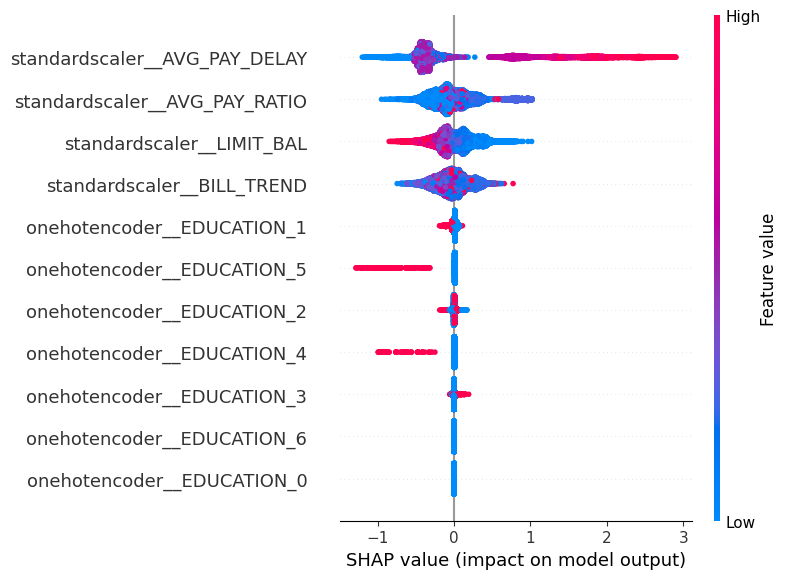

In [23]:

best_lgbm = random_search.best_estimator_.named_steps['lgbmclassifier']
preprocessor = random_search.best_estimator_.named_steps['columntransformer']

X_train_enc = preprocessor.transform(X_train)

if hasattr(X_train_enc, 'toarray'):
    X_train_enc = X_train_enc.toarray()

feature_names = preprocessor.get_feature_names_out()

X_train_enc_df = pd.DataFrame(X_train_enc, columns=feature_names)

explainer = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_train_enc_df)

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

shap.summary_plot(shap_values_to_plot, X_train_enc_df)

The most important feature by far is AVG_PAY_DELAY, created from averaging out all the delay values across the months for each client. Longer delays shows that this feature impacts the possibility of defaulting the most. The 2nd and third most important features are considerably lower on SHAP values, they are AVG_PAY_RATIO and LIMIT_BAL. AVG_PAY_RATIO shows that lower ratios can lead to a higher default risk. LIMIT_BAL has a strong relationship in which lower credit limits correspond to a higher possibility of defaulting. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

C:\Users\richa\miniforge3\envs\cpsc330\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Final Test Accuracy: 0.7362
Final Test Recall: 0.6273
Final Test F1-Score: 0.5073


C:\Users\richa\miniforge3\envs\cpsc330\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



SHAP Waterfall Plot for Test Instance 0:


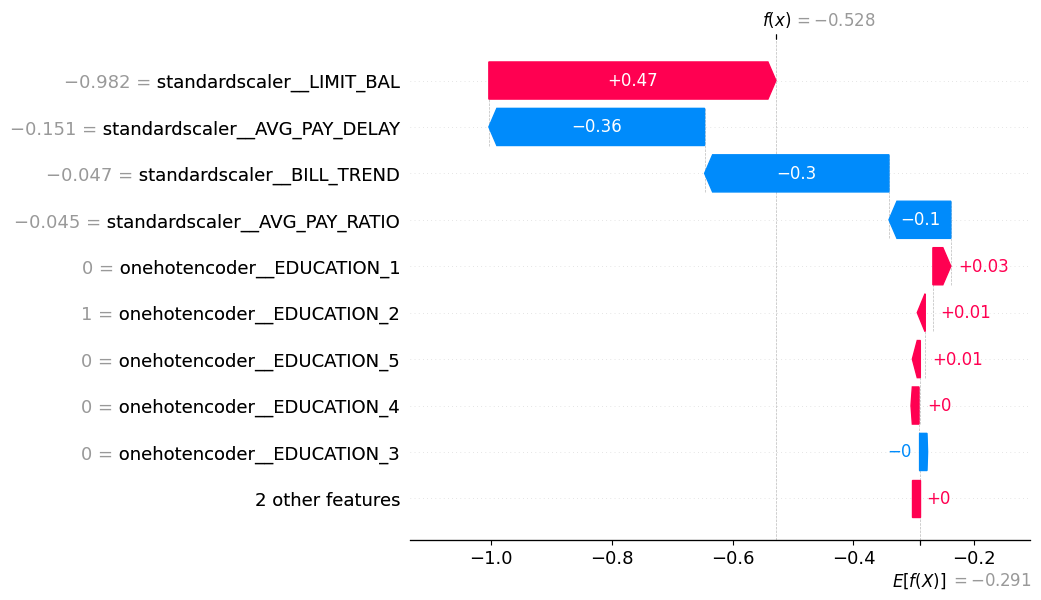

In [24]:
best_pipe = random_search.best_estimator_

y_pred = best_pipe.predict(X_test)

print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Final Test Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Final Test F1-Score: {f1_score(y_test, y_pred):.4f}")

preprocessor = best_pipe.named_steps['columntransformer']
lgbm_model = best_pipe.named_steps['lgbmclassifier']

X_test_enc = preprocessor.transform(X_test)
if hasattr(X_test_enc, 'toarray'):
    X_test_enc = X_test_enc.toarray()

feature_names = preprocessor.get_feature_names_out()
X_test_enc_df = pd.DataFrame(X_test_enc, columns=feature_names)

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_enc_df)

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
    base_value = explainer.expected_value[1]
else:
    shap_values_to_plot = shap_values
    base_value = explainer.expected_value

shap_exp = shap.Explanation(
    values=shap_values_to_plot[0], 
    base_values=base_value, 
    data=X_test_enc_df.iloc[0], 
    feature_names=feature_names
)

print("\nSHAP Waterfall Plot for Test Instance 0:")
shap.waterfall_plot(shap_exp)

**Compare and Reflect**

The test score (0.507) was incredibly close to the validation score (0.526) showing that there were no issues of the model overfitting or underfitting. This small gap also indicates that there was no optimization bias at play. As a result, I highly trust this model's results. 

**Explain Individual Predictions**

This client had a score of -0.528 meaning that they did not default. Like what was seen in the SHAP value chart, AVG_PAY_DELAY and LIMIT_BAL were highly important for the prediction of this client. They held a low credit limit which pushed this risk the most, however this was counteracted by their low pay delay and their decreasing bill to pay. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

| Model | Validation F1-Score | Test F1-Score | Key Observations |
| :--- | :--- | :--- | :--- |
| Linear Model | 0.433 | N/A | Processed quickly and had low validation scores. Showed very low sensitivity to hyperparameter tuning. |
| Decision Tree | 0.378 | N/A | Severely overfitted with high training scores but low validation scores. Was quick to fit. |
| Random Forest | 0.413 | N/A | Very computationally expensive with long fitting times. Also had high overfitting. |
| LightGBM | 0.526 | 0.507 | Significantly stronger model than the rest due to tuning max_depth and n_estimators. |

While it seems obvious, it was still surprising seeing the differences in using average pay delay as a predictor as compared to education. Merging the types of features together into a summariser feature worked quite well as I believed it got rid of any multicollinearity risks. Using feature selection with RFECV did not work well as it degraded the model's performance. Using the decision tree and random forest models also drastically failed with the amount of overfitting done. In the future, I want to test more feature engineering with the dataset as there could be different combinations (averages, ratios or trends) that could work better than the ones I used. 

The final test score is 0.507 from the tuned LightGBM model taken from the F1 score as it balances between precision and recall metrics. 

<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

I've been surprised by how much tuning is required for machine learning. Prior to this course my impression has always just been taking a dataset and running it through a model via code. Turns out there's various metrics that are used to evaluate how a model performs and should fit on the dataset that should be taken into account. I was also surprised by the different types of models that could be used such as LightGBM, DecisionTrees, and RBF with SVC when it comes to classifying. 

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please ensure you have followed all the steps in the **Instructions** section at the top.  

### Submission checklist  

- [ ] Restart the kernel and run all cells (▶▶ button)
- [ ] Make sure to push the most up to date version of your homework assignment to your GitHub repository so that we can use it for grading if there are any problems with your submission on Gradescope. 
- [ ] The `.ipynb` file runs without errors and shows all outputs.  
- [ ] Only the `.ipynb` file and required output files are uploaded (no extra files).  
- [ ] If the `.ipynb` file is too large to render on Gradescope, upload a Web PDF and/or HTML version as well.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)